# Econ 390 - Problem Set 8 Answers
## by M McMain
This problem set will cover Stylesheets & Seaborn and APIs. Be sure to import any packages your code needs to run and make sure the code runs without any errors.

1. Create your own stylesheet with your own personal preferences for plots
   - Write it into a file using the `write` method. Save it as `my_stylesheet.mplstyle`. *Hint: How do we represent new lines when printing?*
   - Use `with` to create a line plot using your new stylesheet of [Crude Oil Prices: Brent - Europe](https://fred.stlouisfed.org/series/DCOILBRENTEU) and [Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma](https://fred.stlouisfed.org/series/DCOILWTICO) over the last 5 years from FRED using pandas_datareader to read in the data. Make sure to include some way to label the lines. *Hint: The codes are in this file.*

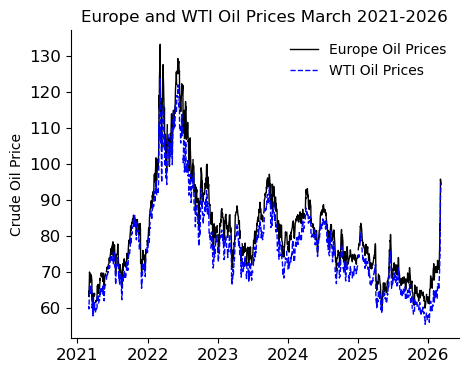

In [10]:
# Import necessary packages
import pandas as pd 
import matplotlib.pyplot as plt
import pandas_datareader.data as web  

# Create the stylesheet
my_file = open('my_stylesheet.mplstyle', 'w')
my_file.write("axes.spines.right: False\naxes.spines.top: False\naxes.prop_cycle : cycler(color=['black','blue','red','orange']) + cycler(linestyle=['-', '--', ':', '-.'])\nfigure.figsize:5,4\nlegend.frameon:False\nlines.linewidth: 1\nxtick.labelsize: 12\nytick.labelsize: 12")
my_file.close() # remember to close file!

# Read in and plot the two series
codes = {'DCOILBRENTEU' : 'Europe Oil Prices', 'DCOILWTICO' :'WTI Oil Prices'}
fred_oil = web.DataReader(codes.keys(), 'fred', start='2021-03-01').rename(columns=codes)
with plt.style.context('my_stylesheet.mplstyle'):
    fig, ax = plt.subplots()
    ax.plot(fred_oil.index, fred_oil['Europe Oil Prices'], label='Europe Oil Prices')
    ax.plot(fred_oil.index, fred_oil['WTI Oil Prices'], label='WTI Oil Prices')
    ax.set_ylabel('Crude Oil Price')
    ax.set_title('Europe and WTI Oil Prices March 2021-2026')
    ax.legend()

plt.show()

2. Using the [World Bank Open Data Website](https://data.worldbank.org/), find the indicator codes for "Primary School Completion Rate, Male (% of relevant age group)" and "Primary School Completion Rate, Female (% of relevant age group)".
   - Using pandas-datareader, download these two indicators from 1995 to present. In your wb.download() statement, use the argument country='WLD', which will give you a single datapoint for each indicator per year (reflecting the percentage of males and females that completed primary school worldwide in that year). (You may get a warning that WLD is a non-standard ISO country code, which you can ignore. If you like, you can also use the argument errors='ignore' to suppress this warning.)
   - Store the resulting data in a DataFrame named primary_percent_complete.
   - Make a line plot that shows how both of these indicators have evolved from 1995 to present, with both lines appearing on the same axes in the same figure. Include a legend that makes it clear which line is which, and title the figure and the y-axis appropriately.
   - *Hint: Before plotting the data, you'll want to reset the index on the DataFrame, convert the year column from str to int, and then set the year column as the row index.*

C:\Users\micha\AppData\Local\Temp\ipykernel_28076\3713549682.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  primary_percent_complete = wb.download(indicator=indicators.keys(),


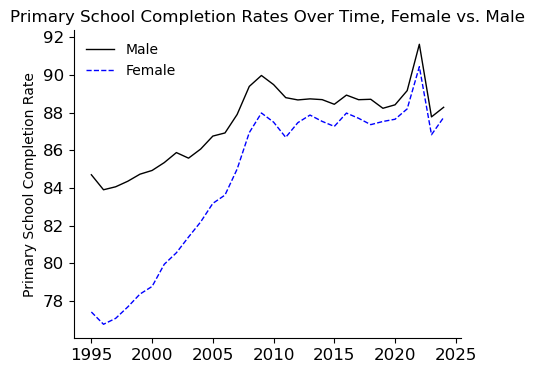

In [37]:
from pandas_datareader import wb
from datetime import datetime

# Define parameters
indicators={'SE.PRM.CMPT.MA.ZS':'Primary School Completion Rate, Male', 'SE.PRM.CMPT.FE.ZS':'Primary School Completion Rate, Female'}

# Get data from World Bank
primary_percent_complete = wb.download(indicator=indicators.keys(), 
                                       country="WLD",
                                       start=1970,
                                       errors="ignore",
                                       end=2026).rename(columns=indicators)

primary_percent_complete = primary_percent_complete.reset_index()
primary_percent_complete["year"] = primary_percent_complete["year"].astype(int)
primary_percent_complete = primary_percent_complete.set_index("year")
with plt.style.context('my_stylesheet.mplstyle'):
    fig, ax = plt.subplots()
    ax.plot(primary_percent_complete.index, primary_percent_complete['Primary School Completion Rate, Male'], label='Male')
    ax.plot(primary_percent_complete.index, primary_percent_complete['Primary School Completion Rate, Female'], label='Female')
    ax.set_ylabel('Primary School Completion Rate')
    ax.set_title('Primary School Completion Rates Over Time, Female vs. Male')
    ax.legend()

plt.show()
